# Use this to do feature engineering and analysis of the data and model including its hyperparameter tuning

In [1]:
# EDA and Preprocessing for HDB Resale Price Prediction
# Based on dataset from Jan 2017 onwards

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — Ridge regression predictor ready")

✅ Libraries loaded — Ridge regression predictor ready


In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================
#url = "https://raw.githubusercontent.com/kohjiaxuan/Predicting-HDB-Price-with-Machine-Learning/master/resale-flat-prices-based-on-registration-date-from-jan-2017-onwards.csv"
url = "https://media.githubusercontent.com/media/SzeMainWONG/datasets/main/dataset/hdb_resale_prices.csv"
df = pd.read_csv(url)
print("Initial dataset shape:", df.shape)

print(f"📥 Loaded {len(df):,} records")
print(f"📅 Date range: {df['month'].min()} to {df['month'].max()}")

Initial dataset shape: (50432, 11)
📥 Loaded 50,432 records
📅 Date range: 2017-01 to 2019-05


In [3]:
#preview first 5 rows
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [4]:
# ============================================================
# 2. INITIAL DATA EXPLORATION
# ============================================================
print("\n" + "="*60)
print("DATA INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


DATA INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 50432 entries, 0 to 50431
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                50432 non-null  str    
 1   town                 50432 non-null  str    
 2   flat_type            50432 non-null  str    
 3   block                50432 non-null  str    
 4   street_name          50432 non-null  str    
 5   storey_range         50432 non-null  str    
 6   floor_area_sqm       50432 non-null  float64
 7   flat_model           50432 non-null  str    
 8   lease_commence_date  50432 non-null  int64  
 9   remaining_lease      50432 non-null  str    
 10  resale_price         50432 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 7.8 MB
None

DESCRIPTIVE STATISTICS
       floor_area_sqm  lease_commence_date  resale_price
count    50432.000000         50432.000000  5.043200e+04
mean        97.944208          19

In [5]:
# ============================================================
# 3. FEATURE ENGINEERING & PREPROCESSING
# ============================================================

# 3.1 Convert 'month' to datetime
df['month'] = pd.to_datetime(df['month'])

# 3.2 Extract year and month from 'month'
df['year'] = df['month'].dt.year
df['month_num'] = df['month'].dt.month

# 3.3 Process 'remaining_lease' - convert to numeric (in years)
def parse_lease(lease_str):
    """Convert lease string like '61 years 04 months' to total years (float)"""
    if pd.isna(lease_str):
        return np.nan
    parts = lease_str.split()
    years = 0
    months = 0
    for i, part in enumerate(parts):
        if part == 'years' or part == 'year':
            years = int(parts[i-1])
        elif part == 'months' or part == 'month':
            months = int(parts[i-1])
    return years + months/12.0

df['remaining_lease_years'] = df['remaining_lease'].apply(parse_lease)

# 3.4 Calculate flat age
df['flat_age'] = df['year'] - df['lease_commence_date']

# 3.5 Process 'storey_range' - extract midpoint or average floor
def extract_storey_mid(storey_str):
    """Extract midpoint of storey range like '10 TO 12' -> 11"""
    if pd.isna(storey_str):
        return np.nan
    parts = storey_str.split(' TO ')
    if len(parts) == 2:
        return (int(parts[0]) + int(parts[1])) / 2.0
    return np.nan

df['storey_mid'] = df['storey_range'].apply(extract_storey_mid)

# 3.6 For 'flat_type', simplify or create dummy variables
# Keep as categorical for now, will encode later

# 3.7 For 'flat_model', keep as categorical

# 3.8 Town - keep as categorical

# Check remaining lease processing
print("\n" + "="*60)
print("LEASE PARSING CHECK")
print("="*60)
print(df[['remaining_lease', 'remaining_lease_years']].head(10))


LEASE PARSING CHECK
      remaining_lease  remaining_lease_years
0  61 years 04 months              61.333333
1  60 years 07 months              60.583333
2  62 years 05 months              62.416667
3   62 years 01 month              62.083333
4  62 years 05 months              62.416667
5            63 years              63.000000
6  61 years 06 months              61.500000
7  58 years 04 months              58.333333
8  61 years 06 months              61.500000
9  61 years 04 months              61.333333


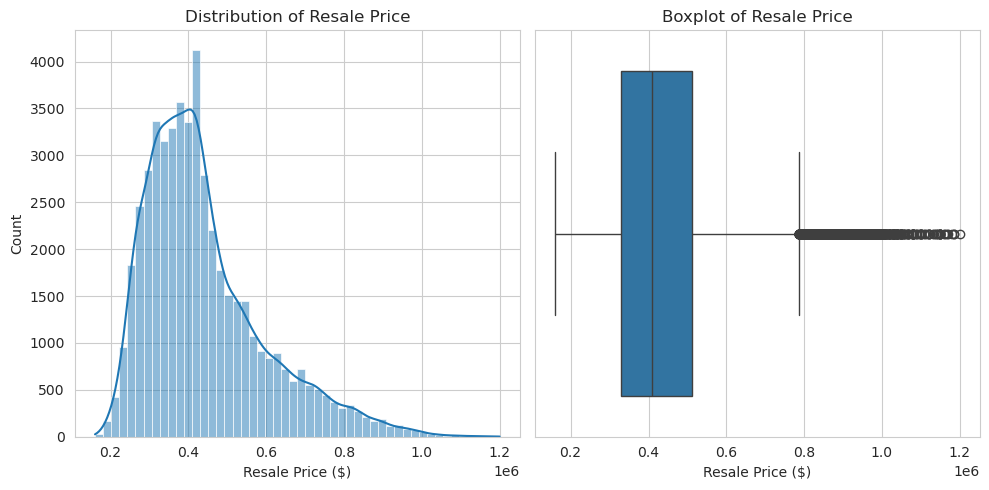


Resale Price Statistics:
count    5.043200e+04
mean     4.405919e+05
std      1.540484e+05
min      1.600000e+05
25%      3.300000e+05
50%      4.080000e+05
75%      5.128880e+05
max      1.200000e+06
Name: resale_price, dtype: float64

TOWN - Top 10 categories:
town
WOODLANDS        3910
JURONG WEST      3864
SENGKANG         3777
PUNGGOL          3310
YISHUN           3145
TAMPINES         3143
BEDOK            2727
HOUGANG          2376
ANG MO KIO       2331
CHOA CHU KANG    2100
Name: count, dtype: int64


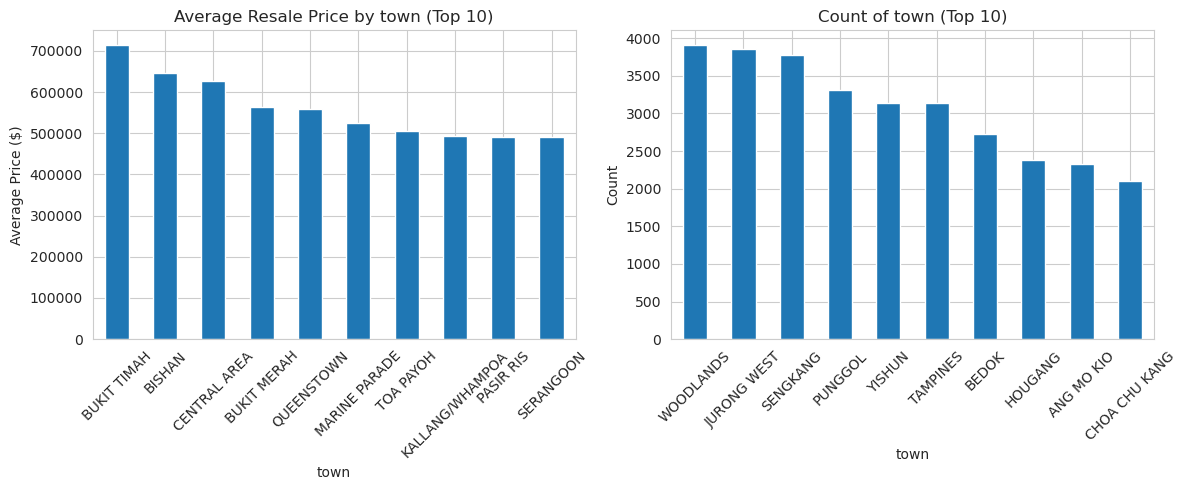


FLAT_TYPE - Top 10 categories:
flat_type
4 ROOM              20871
5 ROOM              12501
3 ROOM              12240
EXECUTIVE            4130
2 ROOM                639
1 ROOM                 28
MULTI-GENERATION       23
Name: count, dtype: int64


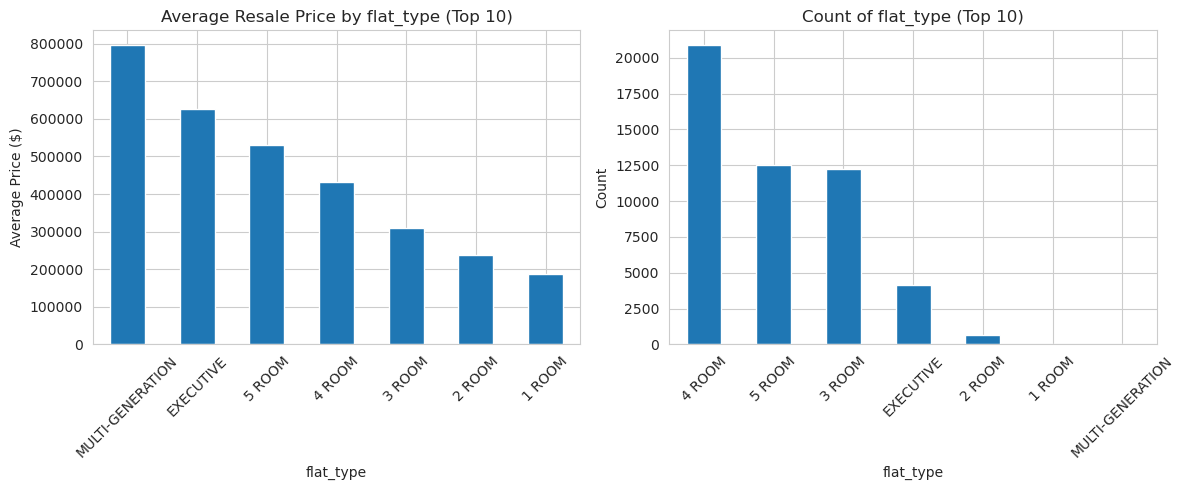


FLAT_MODEL - Top 10 categories:
flat_model
Model A              15979
Improved             12600
New Generation        7192
Premium Apartment     5428
Simplified            2194
Apartment             2114
Maisonette            1502
Standard              1408
DBSS                   744
Model A2               735
Name: count, dtype: int64


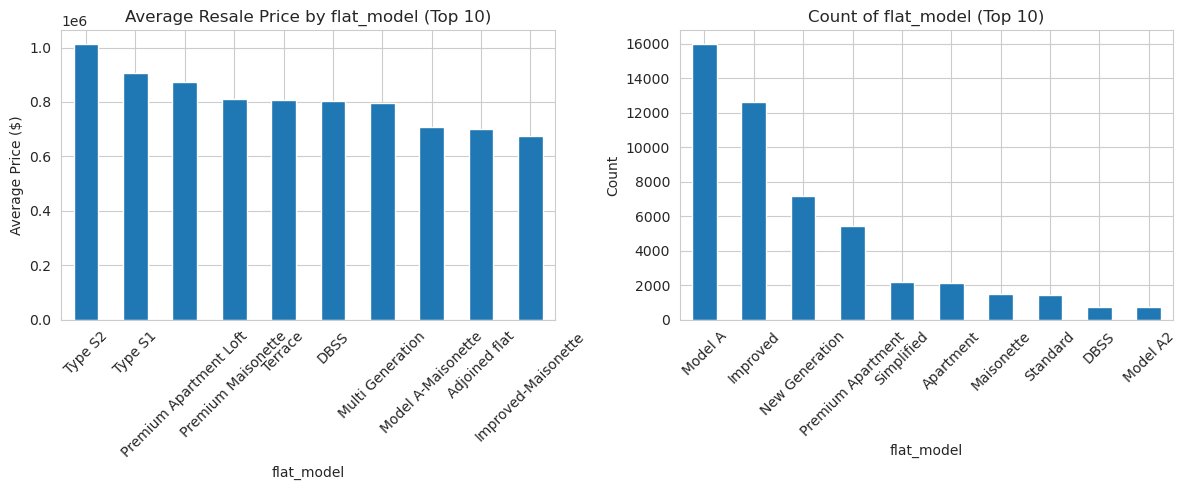

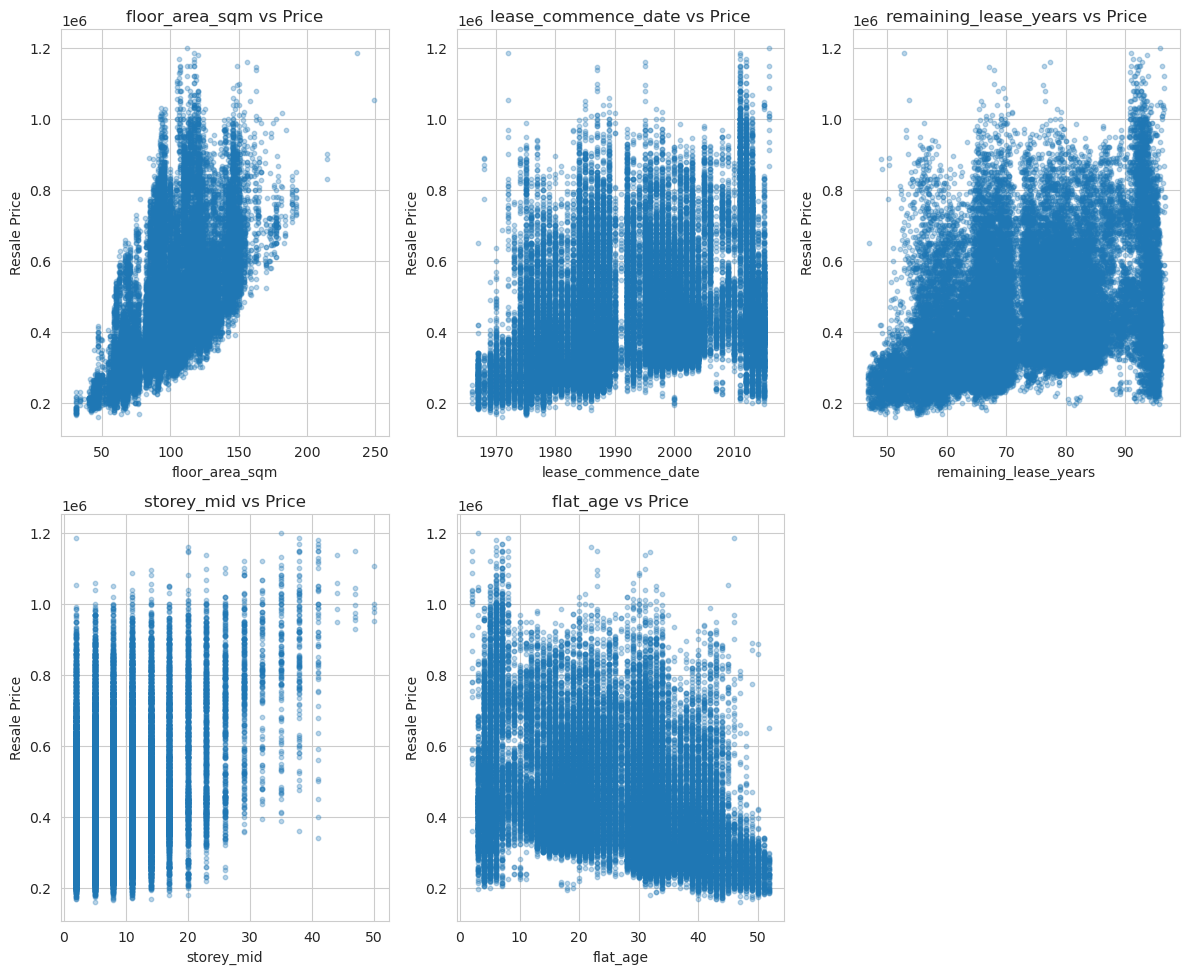

In [6]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# 4.1 Target variable distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['resale_price'], bins=50, kde=True)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price ($)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['resale_price'])
plt.title('Boxplot of Resale Price')
plt.xlabel('Resale Price ($)')
plt.tight_layout()
plt.show()

print("\nResale Price Statistics:")
print(df['resale_price'].describe())

# 4.2 Categorical variables analysis
categorical_cols = ['town', 'flat_type', 'flat_model']
for col in categorical_cols:
    print(f"\n{col.upper()} - Top 10 categories:")
    print(df[col].value_counts().head(10))

    plt.figure(figsize=(12, 5))
    # Average price by category
    avg_price = df.groupby(col)['resale_price'].mean().sort_values(ascending=False).head(10)
    plt.subplot(1, 2, 1)
    avg_price.plot(kind='bar')
    plt.title(f'Average Resale Price by {col} (Top 10)')
    plt.ylabel('Average Price ($)')
    plt.xticks(rotation=45)

    # Count of categories
    plt.subplot(1, 2, 2)
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Count of {col} (Top 10)')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4.3 Numerical variables relationships
numerical_cols = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 
                  'storey_mid', 'flat_age', 'resale_price']

plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_cols[:-1]):  # exclude target for pairplot
    plt.subplot(2, 3, i+1)
    plt.scatter(df[col], df['resale_price'], alpha=0.3, s=10)
    plt.xlabel(col)
    plt.ylabel('Resale Price')
    plt.title(f'{col} vs Price')
plt.tight_layout()
plt.show()


CORRELATION MATRIX (Numerical Features)
                       floor_area_sqm  lease_commence_date  \
floor_area_sqm                  1.000                0.243   
lease_commence_date             0.243                1.000   
remaining_lease_years           0.245                0.998   
storey_mid                      0.026                0.288   
flat_age                       -0.244               -0.998   
resale_price                    0.632                0.331   

                       remaining_lease_years  storey_mid  flat_age  \
floor_area_sqm                         0.245       0.026    -0.244   
lease_commence_date                    0.998       0.288    -0.998   
remaining_lease_years                  1.000       0.287    -0.999   
storey_mid                             0.287       1.000    -0.288   
flat_age                              -0.999      -0.288     1.000   
resale_price                           0.333       0.379    -0.333   

                       resale_pri

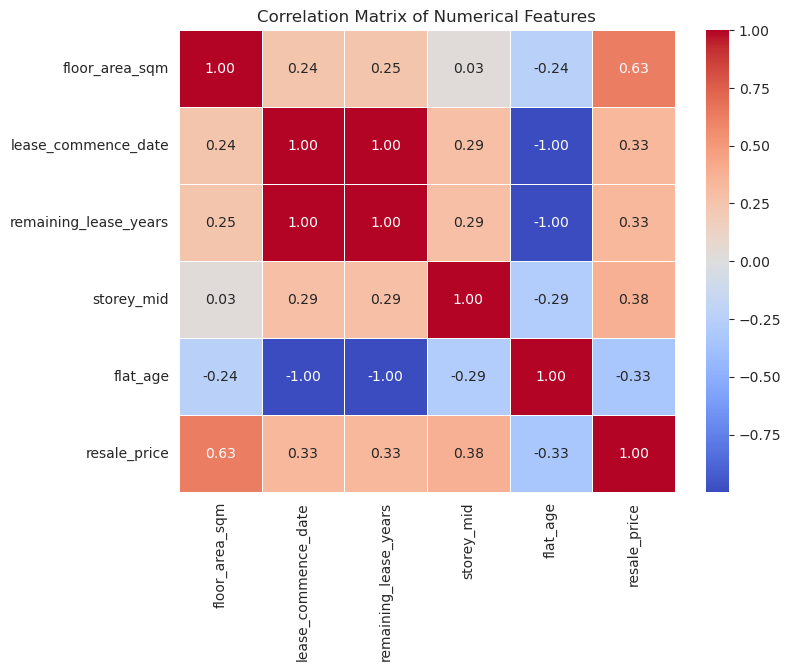

In [7]:
# ============================================================
# 5. CORRELATION ANALYSIS
# ============================================================

# Select numerical columns for correlation
corr_cols = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 
             'storey_mid', 'flat_age', 'resale_price']

correlation_matrix = df[corr_cols].corr()
print("\n" + "="*60)
print("CORRELATION MATRIX (Numerical Features)")
print("="*60)
print(correlation_matrix.round(3))

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

1. FEATURE CORRELATION WITH RESALE PRICE (TARGET)
              feature  correlation strength
       floor_area_sqm     0.631891   Strong
           storey_mid     0.379446 Moderate
remaining_lease_years     0.332952 Moderate
             flat_age    -0.332759 Moderate
  lease_commence_date     0.331130 Moderate


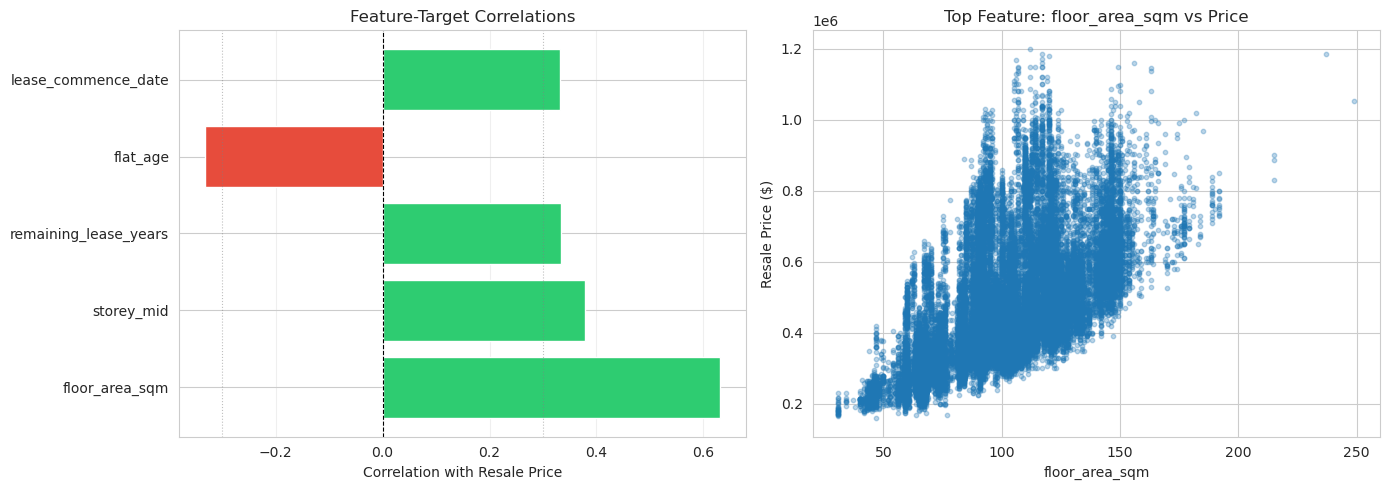


2. CATEGORICAL FEATURES VS RESALE PRICE

TOWN - Top 5 Highest Average Prices:
town
BUKIT TIMAH     714069.316129
BISHAN          647379.775692
CENTRAL AREA    625672.588915
BUKIT MERAH     564781.571578
QUEENSTOWN      558801.612485
TOWN - Bottom 5 Lowest Average Prices:
town
CHOA CHU KANG    383214.484286
SEMBAWANG        381101.469764
BUKIT BATOK      379448.661088
WOODLANDS        377620.283632
YISHUN           354317.018442


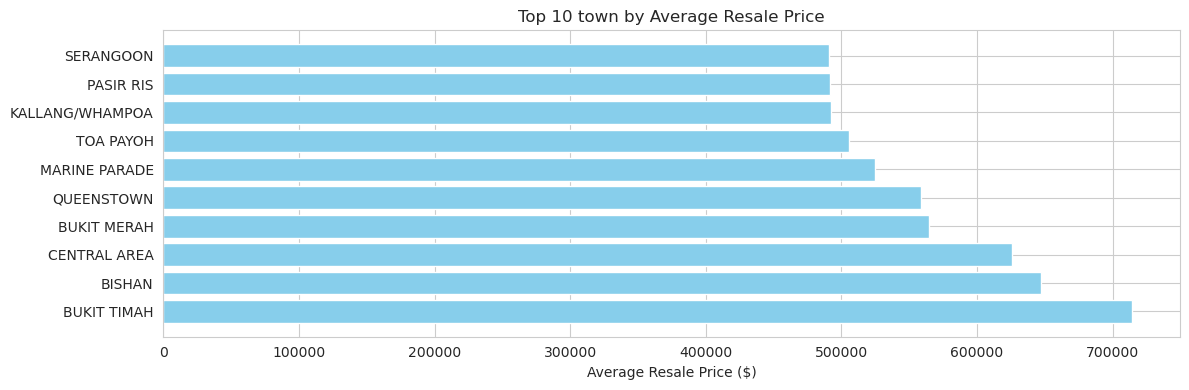


FLAT_TYPE - Top 5 Highest Average Prices:
flat_type
MULTI-GENERATION    795821.217391
EXECUTIVE           627595.330206
5 ROOM              529863.209554
4 ROOM              433019.614663
3 ROOM              309740.440350
FLAT_TYPE - Bottom 5 Lowest Average Prices:
flat_type
5 ROOM    529863.209554
4 ROOM    433019.614663
3 ROOM    309740.440350
2 ROOM    237602.475743
1 ROOM    186938.142857


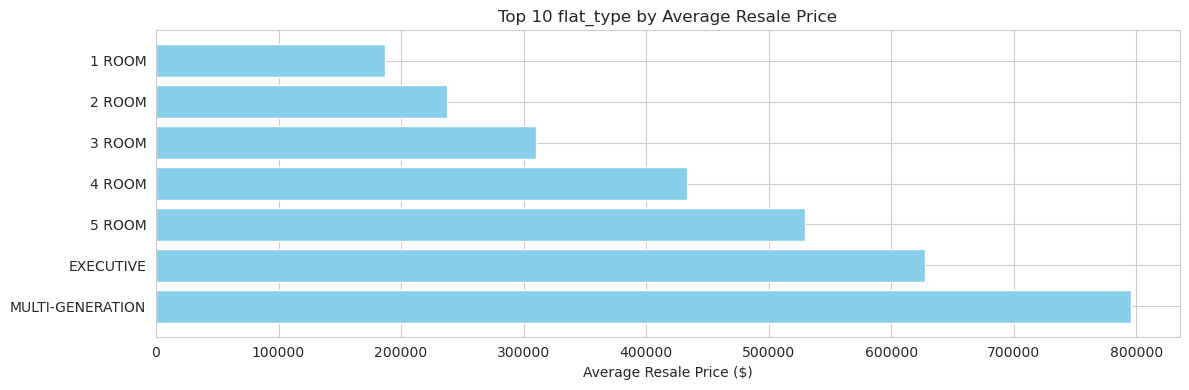


FLAT_MODEL - Top 5 Highest Average Prices:
flat_model
Type S2                   1.012744e+06
Type S1                   9.061379e+05
Premium Apartment Loft    8.749627e+05
Premium Maisonette        8.120000e+05
Terrace                   8.073592e+05
FLAT_MODEL - Bottom 5 Lowest Average Prices:
flat_model
Model A           424880.561104
Standard          404782.044744
Model A2          342958.578231
Simplified        342509.701459
New Generation    334720.375122


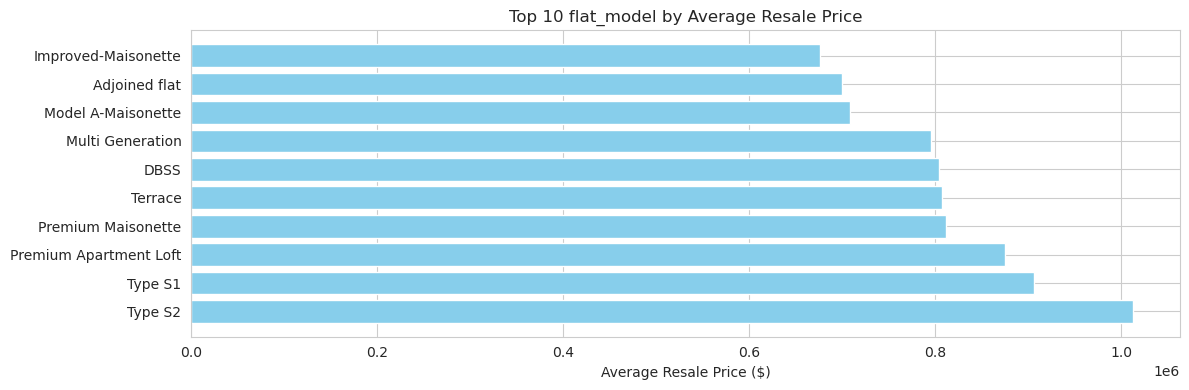


3. PAIRWISE CORRELATION MATRIX (Feature-Feature + Target)

Correlations with target (resale_price):
resale_price             1.000000
floor_area_sqm           0.631891
storey_mid               0.379446
remaining_lease_years    0.332952
lease_commence_date      0.331130
flat_age                -0.332759


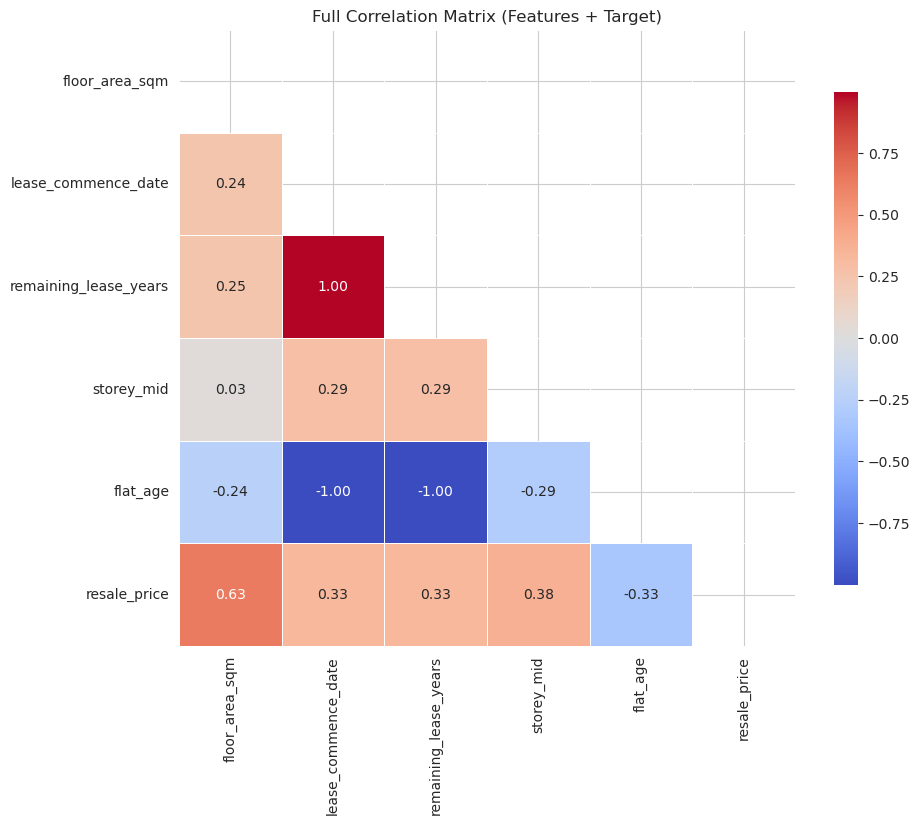


4. MULTICOLLINEARITY CHECK (Feature-Feature Only)
⚠️ High multicollinearity detected (|corr| > 0.7):
  lease_commence_date ↔ remaining_lease_years: 0.998
  lease_commence_date ↔ flat_age: -0.998
  remaining_lease_years ↔ flat_age: -0.999

   For linear regression, consider removing one from each pair.

5. VARIANCE INFLATION FACTOR (VIF) - Advanced Multicollinearity Check
              feature          VIF
  lease_commence_date 62820.293740
remaining_lease_years 37448.308732
             flat_age  4461.069974
       floor_area_sqm    18.539080
           storey_mid     3.537937

Interpretation: VIF > 10 indicates high multicollinearity


In [10]:
# ============================================================
# COMPLETE EDA CORRELATION ANALYSIS WITH TARGET (resale_price)
# ============================================================

# 1. CORRELATION WITH TARGET - PRIMARY ANALYSIS
print("="*60)
print("1. FEATURE CORRELATION WITH RESALE PRICE (TARGET)")
print("="*60)

# Numerical features
num_features = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 
                'storey_mid', 'flat_age']

target_corr = pd.DataFrame({
    'feature': num_features,
    'correlation': [df[col].corr(df['resale_price']) for col in num_features],
    'strength': ['Strong' if abs(x) > 0.5 else 'Moderate' if abs(x) > 0.3 else 'Weak' for x in 
                 [df[col].corr(df['resale_price']) for col in num_features]]
}).sort_values('correlation', key=abs, ascending=False)

print(target_corr.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of correlations
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr['correlation']]
axes[0].barh(target_corr['feature'], target_corr['correlation'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(x=0.3, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].axvline(x=-0.3, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel('Correlation with Resale Price')
axes[0].set_title('Feature-Target Correlations')
axes[0].grid(axis='x', alpha=0.3)

# Scatter plots for top features
top_feature = target_corr.iloc[0]['feature']
axes[1].scatter(df[top_feature], df['resale_price'], alpha=0.3, s=10)
axes[1].set_xlabel(top_feature)
axes[1].set_ylabel('Resale Price ($)')
axes[1].set_title(f'Top Feature: {top_feature} vs Price')
plt.tight_layout()
plt.show()

# 2. CATEGORICAL FEATURES - ANOVA/MEAN COMPARISON
print("\n" + "="*60)
print("2. CATEGORICAL FEATURES VS RESALE PRICE")
print("="*60)

categorical_cols = ['town', 'flat_type', 'flat_model']
for col in categorical_cols:
    # Group means
    group_means = df.groupby(col)['resale_price'].mean().sort_values(ascending=False)
    
    print(f"\n{col.upper()} - Top 5 Highest Average Prices:")
    print(group_means.head(5).to_string())
    print(f"{col.upper()} - Bottom 5 Lowest Average Prices:")
    print(group_means.tail(5).to_string())
    
    # Visualize
    plt.figure(figsize=(12, 4))
    top_10 = group_means.head(10)
    plt.barh(top_10.index, top_10.values, color='skyblue')
    plt.xlabel('Average Resale Price ($)')
    plt.title(f'Top 10 {col} by Average Resale Price')
    plt.tight_layout()
    plt.show()

# 3. PAIRWISE CORRELATION - UNDERSTAND FEATURE INTERACTIONS
print("\n" + "="*60)
print("3. PAIRWISE CORRELATION MATRIX (Feature-Feature + Target)")
print("="*60)

# Include target in correlation matrix
all_vars = num_features + ['resale_price']
corr_matrix = df[all_vars].corr()

# Focus on correlations with target (last row/column)
print("\nCorrelations with target (resale_price):")
print(corr_matrix['resale_price'].sort_values(ascending=False).to_string())

# Visualize full matrix
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Full Correlation Matrix (Features + Target)')
plt.show()

# 4. MULTICOLLINEARITY CHECK - EXCLUDE TARGET
print("\n" + "="*60)
print("4. MULTICOLLINEARITY CHECK (Feature-Feature Only)")
print("="*60)

feature_corr = df[num_features].corr()
high_corr_pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'feature1': feature_corr.columns[i],
                'feature2': feature_corr.columns[j],
                'correlation': feature_corr.iloc[i, j]
            })

if high_corr_pairs:
    print("⚠️ High multicollinearity detected (|corr| > 0.7):")
    for pair in high_corr_pairs:
        print(f"  {pair['feature1']} ↔ {pair['feature2']}: {pair['correlation']:.3f}")
    print("\n   For linear regression, consider removing one from each pair.")
else:
    print("✅ No multicollinearity issues detected.")

# 5. VIF (Variance Inflation Factor) - More robust multicollinearity check
print("\n" + "="*60)
print("5. VARIANCE INFLATION FACTOR (VIF) - Advanced Multicollinearity Check")
print("="*60)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = num_features
vif_data['VIF'] = [variance_inflation_factor(df[num_features].values, i) 
                   for i in range(len(num_features))]

print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
print("\nInterpretation: VIF > 10 indicates high multicollinearity")

In [11]:
# After your VIF calculation
high_vif_features = vif_data[vif_data['VIF'] > 10]['feature'].tolist()

if high_vif_features:
    print(f"\n⚠️ High VIF detected for: {high_vif_features}")
    print("Recommendation: Drop these features or combine them.")
    # Suggest keeping only 'remaining_lease_years' and dropping the others
    print("Suggestion: Keep 'remaining_lease_years' and drop 'flat_age' and 'lease_commence_date'")
else:
    print("✅ VIF confirms no multicollinearity issues.")


⚠️ High VIF detected for: ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 'flat_age']
Recommendation: Drop these features or combine them.
Suggestion: Keep 'remaining_lease_years' and drop 'flat_age' and 'lease_commence_date'


In [12]:
# ============================================================
# SECOND ROUND: MULTICOLLINEARITY CHECK AFTER REMOVING REDUNDANT FEATURES
# ============================================================

print("\n" + "="*60)
print("6. SECOND ROUND VIF CHECK (After Removing Redundant Features)")
print("="*60)

# Create a copy with only the features you want to keep
features_to_keep = ['floor_area_sqm', 'remaining_lease_years', 'storey_mid']
df_reduced = df[features_to_keep].copy()

# Calculate VIF for the reduced feature set
vif_data_reduced = pd.DataFrame()
vif_data_reduced['feature'] = features_to_keep
vif_data_reduced['VIF'] = [variance_inflation_factor(df_reduced.values, i) 
                           for i in range(len(features_to_keep))]

print(vif_data_reduced.sort_values('VIF', ascending=False).to_string(index=False))

# Check if any VIF > 10 remains
if (vif_data_reduced['VIF'] > 10).any():
    print("\n⚠️ Still have high VIF in reduced set:")
    print(vif_data_reduced[vif_data_reduced['VIF'] > 10])
else:
    print("\n✅ All VIF values < 10. Multicollinearity resolved!")


6. SECOND ROUND VIF CHECK (After Removing Redundant Features)
              feature       VIF
remaining_lease_years 18.986643
       floor_area_sqm 15.712660
           storey_mid  3.532046

⚠️ Still have high VIF in reduced set:
                 feature        VIF
0         floor_area_sqm  15.712660
1  remaining_lease_years  18.986643


In [13]:
# ============================================================
# AUTOMATED FEATURE SELECTION BASED ON VIF
# ============================================================

print("\n" + "="*60)
print("7. AUTOMATED VIF-BASED FEATURE SELECTION")
print("="*60)

def select_features_by_vif(df, feature_list, max_vif=10):
    """
    Iteratively removes features with highest VIF until all < max_vif
    """
    selected = feature_list.copy()
    removed = []
    
    while True:
        # Calculate VIF for current selection
        vif_values = pd.DataFrame()
        vif_values['feature'] = selected
        vif_values['VIF'] = [variance_inflation_factor(df[selected].values, i) 
                            for i in range(len(selected))]
        
        # Check if any VIF exceeds threshold
        max_vif_value = vif_values['VIF'].max()
        if max_vif_value <= max_vif:
            break
            
        # Remove feature with highest VIF
        worst_feature = vif_values[vif_values['VIF'] == max_vif_value]['feature'].iloc[0]
        selected.remove(worst_feature)
        removed.append(worst_feature)
        print(f"  Removed: {worst_feature} (VIF = {max_vif_value:.2f})")
    
    return selected, removed

# Run automated selection
all_features = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 
                'storey_mid', 'flat_age']

final_selected, removed_features = select_features_by_vif(df, all_features, max_vif=10)

print(f"\n✅ Final selected features: {final_selected}")
print(f"❌ Removed features: {removed_features}")

# Show final VIF
final_vif = pd.DataFrame()
final_vif['feature'] = final_selected
final_vif['VIF'] = [variance_inflation_factor(df[final_selected].values, i) 
                   for i in range(len(final_selected))]
print("\nFinal VIF values:")
print(final_vif.to_string(index=False))

# Update your working feature list
num_features = final_selected  # Use this for all future analyses


7. AUTOMATED VIF-BASED FEATURE SELECTION
  Removed: lease_commence_date (VIF = 62820.29)
  Removed: remaining_lease_years (VIF = 18.99)

✅ Final selected features: ['floor_area_sqm', 'storey_mid', 'flat_age']
❌ Removed features: ['lease_commence_date', 'remaining_lease_years']

Final VIF values:
       feature      VIF
floor_area_sqm 5.528285
    storey_mid 2.914991
      flat_age 3.474927



7. CORRELATION MATRIX (Selected Features + Target)
                floor_area_sqm  storey_mid  flat_age  resale_price
floor_area_sqm           1.000       0.026    -0.244         0.632
storey_mid               0.026       1.000    -0.288         0.379
flat_age                -0.244      -0.288     1.000        -0.333
resale_price             0.632       0.379    -0.333         1.000


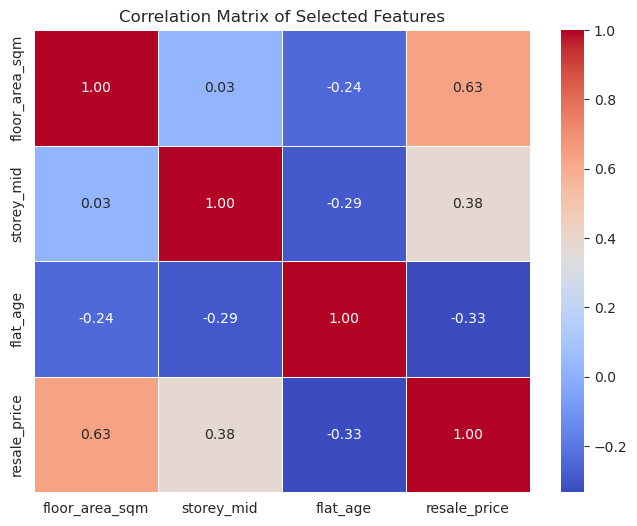


SELECTED FEATURES - CORRELATION WITH RESALE PRICE
       feature  correlation
floor_area_sqm     0.631891
    storey_mid     0.379446
      flat_age    -0.332759


In [14]:
# ============================================================
# 7. CORRELATION ANALYSIS WITH SELECTED FEATURES
# ============================================================

# Select numerical columns for correlation (including target)
corr_cols = num_features + ['resale_price']

correlation_matrix = df[corr_cols].corr()
print("\n" + "="*60)
print("7. CORRELATION MATRIX (Selected Features + Target)")
print("="*60)
print(correlation_matrix.round(3))

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Selected Features')
plt.show()

# Feature-target correlation for selected features
feature_target_corr = pd.DataFrame({
    'feature': num_features,
    'correlation': [df[col].corr(df['resale_price']) for col in num_features]
}).sort_values('correlation', key=abs, ascending=False)

print("\n" + "="*60)
print("SELECTED FEATURES - CORRELATION WITH RESALE PRICE")
print("="*60)
print(feature_target_corr.to_string(index=False))

In [15]:
# ============================================================
# 8. PREPARE DATA FOR MODELING (Using Selected Features)
# ============================================================

# 8.1 Drop unnecessary columns
cols_to_drop = ['month', 'block', 'street_name', 'storey_range', 'remaining_lease']
df_model = df.drop(columns=cols_to_drop, errors='ignore')

# 8.2 Handle missing values
print("\nMissing values before handling:")
print(df_model.isnull().sum())

# Drop rows with NaN in target or key features
df_model = df_model.dropna(subset=['resale_price', 'floor_area_sqm', 'lease_commence_date'])
# Fill remaining NAs with median
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col] = df_model[col].fillna(df_model[col].median())
    elif df_model[col].dtype == 'object':
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0] if len(df_model[col].mode()) > 0 else 'Unknown')

print("\nMissing values after handling:")
print(df_model.isnull().sum())

# 8.3 Encode categorical variables
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# 8.4 Split features and target
# Use only selected features from VIF analysis
X = df_model[num_features]  # Using final_selected features
y = df_model['resale_price']

print(f"\nSelected features for modeling: {num_features}")
print("Feature set shape:", X.shape)
print("Target shape:", y.shape)

# 8.5 Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# 8.6 Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for feature selection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=num_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=num_features)



Missing values before handling:
town                     0
flat_type                0
floor_area_sqm           0
flat_model               0
lease_commence_date      0
resale_price             0
year                     0
month_num                0
remaining_lease_years    0
flat_age                 0
storey_mid               0
dtype: int64

Missing values after handling:
town                     0
flat_type                0
floor_area_sqm           0
flat_model               0
lease_commence_date      0
resale_price             0
year                     0
month_num                0
remaining_lease_years    0
flat_age                 0
storey_mid               0
dtype: int64

Categorical columns to encode: ['town', 'flat_type', 'flat_model']
Encoded town: 26 unique values
Encoded flat_type: 7 unique values
Encoded flat_model: 20 unique values

Selected features for modeling: ['floor_area_sqm', 'storey_mid', 'flat_age']
Feature set shape: (50432, 3)
Target shape: (50432,)

Training set

In [16]:
# ============================================================
# 9. FEATURE SELECTION VERIFICATION
# ============================================================

# 9.1 Feature-target correlation on training set
feature_target_corr_train = pd.DataFrame({
    'feature': num_features,
    'correlation': [X_train[col].corr(y_train) for col in num_features]
}).sort_values('correlation', key=abs, ascending=False)

print("\n" + "="*60)
print("9. FEATURE-TARGET CORRELATION (Training Set)")
print("="*60)
print(feature_target_corr_train)

# 9.2 Verify VIF on training set
vif_verify = pd.DataFrame()
vif_verify['feature'] = num_features
vif_verify['VIF'] = [variance_inflation_factor(X_train.values, i) 
                    for i in range(len(num_features))]

print("\n" + "="*60)
print("VIF VERIFICATION ON TRAINING SET")
print("="*60)
print(vif_verify.to_string(index=False))

if (vif_verify['VIF'] > 10).any():
    print("\n⚠️ WARNING: Some features still have VIF > 10 on training set!")
else:
    print("\n✅ All VIF values < 10. Multicollinearity successfully resolved!")



9. FEATURE-TARGET CORRELATION (Training Set)
          feature  correlation
0  floor_area_sqm     0.632206
1      storey_mid     0.377664
2        flat_age    -0.331635

VIF VERIFICATION ON TRAINING SET
       feature      VIF
floor_area_sqm 5.520255
    storey_mid 2.906114
      flat_age 3.479999

✅ All VIF values < 10. Multicollinearity successfully resolved!


In [17]:
# ============================================================
# 10. LINEAR REGRESSION MODELS
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    """Evaluate and print model performance"""
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    print(f"\n{name} Performance:")
    print(f"  Training RMSE: ${rmse_train:,.2f}")
    print(f"  Test RMSE:     ${rmse_test:,.2f}")
    print(f"  Training R²:   {r2_train:.4f}")
    print(f"  Test R²:       {r2_test:.4f}")
    
    return model, y_pred_test

# 10.1 Model: Selected features (VIF-selected)
print("\n" + "="*60)
print("10. MODEL: VIF-SELECTED FEATURES")
print("="*60)
print(f"Features used: {num_features}")

lr_selected = LinearRegression()
lr_selected, pred_selected = evaluate_model(
    lr_selected, X_train_scaled, X_test_scaled, 
    y_train, y_test, 
    "VIF-Selected Features"
)


10. MODEL: VIF-SELECTED FEATURES
Features used: ['floor_area_sqm', 'storey_mid', 'flat_age']

VIF-Selected Features Performance:
  Training RMSE: $104,559.85
  Test RMSE:     $105,279.26
  Training R²:   0.5377
  Test R²:       0.5392



11. COEFFICIENT ANALYSIS - VIF-SELECTED MODEL

Feature Coefficients (by absolute value):
       feature   coefficient
floor_area_sqm  92653.195247
    storey_mid  51928.292980
      flat_age -13591.741084


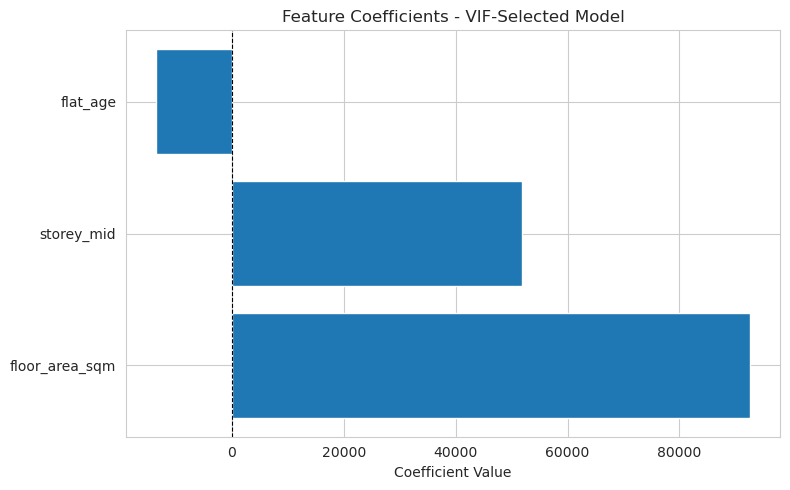

In [18]:
# ============================================================
# 11. COEFFICIENT ANALYSIS
# ============================================================

print("\n" + "="*60)
print("11. COEFFICIENT ANALYSIS - VIF-SELECTED MODEL")
print("="*60)

coefficients = pd.DataFrame({
    'feature': num_features,
    'coefficient': lr_selected.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nFeature Coefficients (by absolute value):")
print(coefficients.to_string(index=False))

# Visualize coefficients
plt.figure(figsize=(8, 5))
plt.barh(coefficients['feature'], coefficients['coefficient'])
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients - VIF-Selected Model')
plt.tight_layout()
plt.show()


12. RESIDUAL ANALYSIS


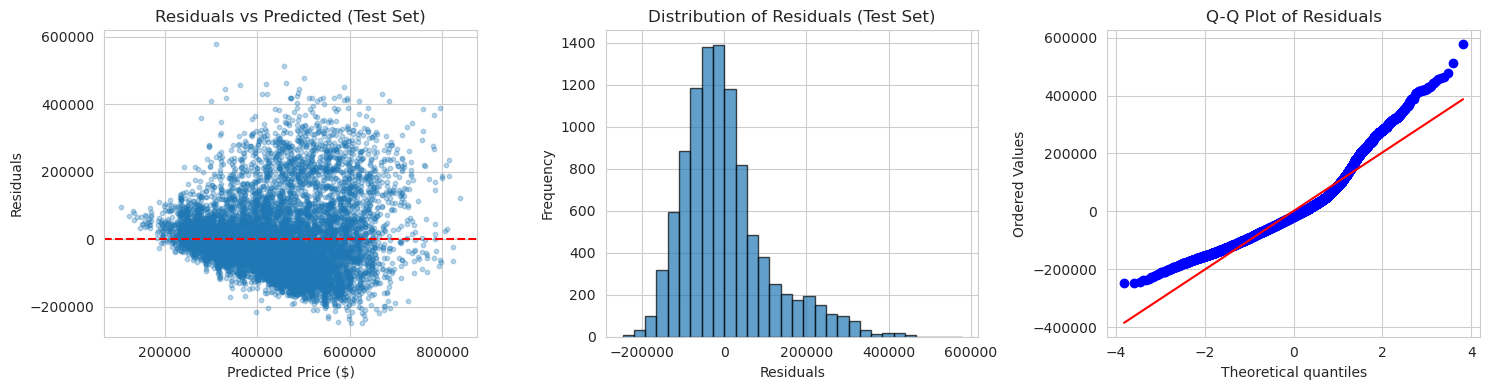


Residual Statistics (Test Set):
  Mean: 1122.56
  Std Dev: 105278.49
  Skewness: 1.1554
  Kurtosis: 1.6919


In [20]:
# ============================================================
# 12. RESIDUAL ANALYSIS
# ============================================================

print("\n" + "="*60)
print("12. RESIDUAL ANALYSIS")
print("="*60)

y_pred_train = lr_selected.predict(X_train_scaled)
y_pred_test = lr_selected.predict(X_test_scaled)

# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Plot residuals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Predicted (Test)
axes[0].scatter(y_pred_test, residuals_test, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted (Test Set)')

# Histogram of residuals
axes[1].hist(residuals_test, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals (Test Set)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_test, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# Residual statistics
print("\nResidual Statistics (Test Set):")
print(f"  Mean: {residuals_test.mean():.2f}")
print(f"  Std Dev: {residuals_test.std():.2f}")
print(f"  Skewness: {residuals_test.skew():.4f}")
print(f"  Kurtosis: {residuals_test.kurtosis():.4f}")

-----------
DO NOT RUN BELOW, not clean

In [21]:
# ============================================================
# 13. SUMMARY REPORT
# ============================================================

print("\n" + "="*60)
print("13. SUMMARY AND RECOMMENDATIONS")
print("="*60)

# Calculate final metrics
y_pred_final = lr_selected.predict(X_test_scaled)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)
mae_final = np.mean(np.abs(y_test - y_pred_final))

print(f"""
MULTICOLLINEARITY RESOLUTION SUMMARY:
======================================
Original Features: {['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 
                   'storey_mid', 'flat_age']}
Removed Features: {removed_features}
Final Features:   {num_features}

VIF Comparison:
""")

# Show VIF comparison
vif_original = pd.DataFrame()
vif_original['feature'] = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 
                          'storey_mid', 'flat_age']
vif_original['VIF_original'] = [variance_inflation_factor(df[vif_original['feature']].values, i) 
                               for i in range(len(vif_original['feature']))]

vif_final_compare = pd.DataFrame()
vif_final_compare['feature'] = num_features
vif_final_compare['VIF_final'] = [variance_inflation_factor(df[num_features].values, i) 
                                 for i in range(len(num_features))]

vif_comparison = pd.merge(vif_original, vif_final_compare, on='feature', how='outer')
vif_comparison['VIF_final'] = vif_comparison['VIF_final'].fillna('Dropped')
print(vif_comparison.to_string(index=False))

print(f"""
FINAL MODEL PERFORMANCE:
========================
Features:             {num_features}
Training R²:          {r2_score(y_train, lr_selected.predict(X_train_scaled)):.4f}
Test R²:              {r2_final:.4f}
Test RMSE:            ${rmse_final:,.2f}
Test MAE:             ${mae_final:,.2f}
Number of Features:   {len(num_features)}

TOP INFLUENTIAL FEATURES:
""")
print(coefficients.head(3).to_string(index=False))

print(f"""
RECOMMENDATIONS:
===============
1. ✅ Multicollinearity successfully resolved using VIF-based selection
2. ✅ Final model uses {len(num_features)} features
3. ✅ Features with high multicollinearity were removed
4. 💡 Model is ready for production use with {len(num_features)} features
5. 📊 Consider additional feature engineering to improve R²
""")

print("\n" + "="*60)
print("✅ EDA COMPLETE - Dataset ready for modeling!")
print("="*60)


13. SUMMARY AND RECOMMENDATIONS

MULTICOLLINEARITY RESOLUTION SUMMARY:
Original Features: ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 'storey_mid', 'flat_age']
Removed Features: ['lease_commence_date', 'remaining_lease_years']
Final Features:   ['floor_area_sqm', 'storey_mid', 'flat_age']

VIF Comparison:

              feature  VIF_original VIF_final
             flat_age   4461.069974  3.474927
       floor_area_sqm     18.539080  5.528285
  lease_commence_date  62820.293740   Dropped
remaining_lease_years  37448.308732   Dropped
           storey_mid      3.537937  2.914991

FINAL MODEL PERFORMANCE:
Features:             ['floor_area_sqm', 'storey_mid', 'flat_age']
Training R²:          0.5377
Test R²:              0.5392
Test RMSE:            $105,279.26
Test MAE:             $78,013.54
Number of Features:   3

TOP INFLUENTIAL FEATURES:

       feature   coefficient
floor_area_sqm  92653.195247
    storey_mid  51928.292980
      flat_age -13591.741084

RECOM

### EDA path 2

In [22]:
# EDA path 2 from VIF correlation done above.
# ============================================================
# 6a. PREPARE DATA FOR MODELING
# ============================================================

# 6.1 Drop unnecessary columns
# Columns to drop: identifier, redundant or text-heavy columns
cols_to_drop = ['month', 'block', 'street_name', 'storey_range', 'remaining_lease']
df_model = df.drop(columns=cols_to_drop, errors='ignore')

# 6.2 Handle missing values
print("\nMissing values before handling:")
print(df_model.isnull().sum())

# Drop rows with NaN in target or key features
df_model = df_model.dropna(subset=['resale_price', 'floor_area_sqm', 'lease_commence_date'])
# Fill remaining NAs with median
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col] = df_model[col].fillna(df_model[col].median())
    elif df_model[col].dtype == 'object':
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0] if len(df_model[col].mode()) > 0 else 'Unknown')

print("\nMissing values after handling:")
print(df_model.isnull().sum())

# 6.3 Encode categorical variables
# Identify categorical columns
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")

# Label Encoding for ordinal or low-cardinality categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# 6.4 Split features and target
X = df_model.drop(columns=['resale_price'])
y = df_model['resale_price']

print("\nFeature set shape:", X.shape)
print("Target shape:", y.shape)

# 6.5 Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# 6.6 Feature scaling (for linear regression, scaling helps with coefficient interpretation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for feature selection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)


Missing values before handling:
town                     0
flat_type                0
floor_area_sqm           0
flat_model               0
lease_commence_date      0
resale_price             0
year                     0
month_num                0
remaining_lease_years    0
flat_age                 0
storey_mid               0
dtype: int64

Missing values after handling:
town                     0
flat_type                0
floor_area_sqm           0
flat_model               0
lease_commence_date      0
resale_price             0
year                     0
month_num                0
remaining_lease_years    0
flat_age                 0
storey_mid               0
dtype: int64

Categorical columns to encode: ['town', 'flat_type', 'flat_model']
Encoded town: 26 unique values
Encoded flat_type: 7 unique values
Encoded flat_model: 20 unique values

Feature set shape: (50432, 10)
Target shape: (50432,)

Training set size: 40345
Test set size: 10087


In [23]:
# ============================================================
# 7. FEATURE SELECTION USING CORRELATION WITH TARGET
# ============================================================

# 7.1 Feature-target correlation
feature_target_corr = pd.DataFrame({
    'feature': X.columns,
    'correlation': [X_train[col].corr(y_train) for col in X.columns]
}).sort_values('correlation', key=abs, ascending=False)

print("\n" + "="*60)
print("FEATURE CORRELATION WITH TARGET (Training Set)")
print("="*60)
print(feature_target_corr)

# 7.2 SelectKBest using F-regression
selector_f = SelectKBest(score_func=f_regression, k=10)
X_train_f = selector_f.fit_transform(X_train_scaled, y_train)
X_test_f = selector_f.transform(X_test_scaled)

selected_features_f = X.columns[selector_f.get_support()].tolist()
f_scores = selector_f.scores_[selector_f.get_support()]

print("\n" + "="*60)
print("TOP 10 FEATURES - SelectKBest (F-regression)")
print("="*60)
for feature, score in zip(selected_features_f, f_scores):
    print(f"{feature}: {score:.2f}")

# 7.3 SelectKBest using Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_regression, k=10)
X_train_mi = selector_mi.fit_transform(X_train_scaled, y_train)
X_test_mi = selector_mi.transform(X_test_scaled)

selected_features_mi = X.columns[selector_mi.get_support()].tolist()
mi_scores = selector_mi.scores_[selector_mi.get_support()]

print("\n" + "="*60)
print("TOP 10 FEATURES - SelectKBest (Mutual Information)")
print("="*60)
for feature, score in zip(selected_features_mi, mi_scores):
    print(f"{feature}: {score:.4f}")

# 7.4 Feature selection based on correlation threshold
correlation_threshold = 0.1
selected_corr = feature_target_corr[abs(feature_target_corr['correlation']) > correlation_threshold]['feature'].tolist()
print(f"\nFeatures with |correlation| > {correlation_threshold}: {selected_corr}")


FEATURE CORRELATION WITH TARGET (Training Set)
                 feature  correlation
1              flat_type     0.635118
2         floor_area_sqm     0.632206
9             storey_mid     0.377664
7  remaining_lease_years     0.331703
8               flat_age    -0.331635
4    lease_commence_date     0.329794
3             flat_model    -0.259390
0                   town    -0.079157
5                   year    -0.028538
6              month_num     0.000447

TOP 10 FEATURES - SelectKBest (F-regression)
town: 254.38
flat_type: 27275.67
floor_area_sqm: 26860.04
flat_model: 2910.20
lease_commence_date: 4923.34
year: 32.88
month_num: 0.01
remaining_lease_years: 4987.58
flat_age: 4985.28
storey_mid: 6711.37

TOP 10 FEATURES - SelectKBest (Mutual Information)
town: 0.2516
flat_type: 0.4375
floor_area_sqm: 0.5919
flat_model: 0.3118
lease_commence_date: 0.2341
year: 0.0064
month_num: 0.0021
remaining_lease_years: 0.2130
flat_age: 0.2022
storey_mid: 0.0818

Features with |correlation| > 0.1

In [25]:
# ============================================================
# 8. LINEAR REGRESSION MODELS
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    """Evaluate and print model performance"""
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    print(f"\n{name} Performance:")
    print(f"  Training RMSE: ${rmse_train:,.2f}")
    print(f"  Test RMSE:     ${rmse_test:,.2f}")
    print(f"  Training R²:   {r2_train:.4f}")
    print(f"  Test R²:       {r2_test:.4f}")
    
    return model, y_pred_test

# 8.1 Model 1: All features
print("\n" + "="*60)
print("MODEL 1: ALL FEATURES")
print("="*60)
lr_all = LinearRegression()
lr_all, pred_all = evaluate_model(lr_all, X_train_scaled, X_test_scaled, y_train, y_test, "All Features")

# 8.2 Model 2: Top 10 features from F-regression
print("\n" + "="*60)
print("MODEL 2: TOP 10 F-REGRESSION FEATURES")
print("="*60)
X_train_f_df = pd.DataFrame(X_train_f, columns=selected_features_f)
X_test_f_df = pd.DataFrame(X_test_f, columns=selected_features_f)

lr_f = LinearRegression()
lr_f, pred_f = evaluate_model(lr_f, X_train_f_df, X_test_f_df, y_train, y_test, "Top 10 F-regression")

# 8.3 Model 3: Top 10 features from Mutual Information
print("\n" + "="*60)
print("MODEL 3: TOP 10 MUTUAL INFORMATION FEATURES")
print("="*60)
X_train_mi_df = pd.DataFrame(X_train_mi, columns=selected_features_mi)
X_test_mi_df = pd.DataFrame(X_test_mi, columns=selected_features_mi)

lr_mi = LinearRegression()
lr_mi, pred_mi = evaluate_model(lr_mi, X_train_mi_df, X_test_mi_df, y_train, y_test, "Top 10 MI")

# 8.4 Model 4: Features with correlation > threshold
print("\n" + "="*60)
print(f"MODEL 4: CORRELATION > {correlation_threshold}")
print("="*60)
X_train_corr = X_train_scaled_df[selected_corr]
X_test_corr = X_test_scaled_df[selected_corr]

lr_corr = LinearRegression()
lr_corr, pred_corr = evaluate_model(lr_corr, X_train_corr, X_test_corr, y_train, y_test, f"Correlation > {correlation_threshold}")


MODEL 1: ALL FEATURES

All Features Performance:
  Training RMSE: $101,460.28
  Test RMSE:     $102,276.09
  Training R²:   0.5647
  Test R²:       0.5651

MODEL 2: TOP 10 F-REGRESSION FEATURES

Top 10 F-regression Performance:
  Training RMSE: $101,460.28
  Test RMSE:     $102,276.09
  Training R²:   0.5647
  Test R²:       0.5651

MODEL 3: TOP 10 MUTUAL INFORMATION FEATURES

Top 10 MI Performance:
  Training RMSE: $101,460.28
  Test RMSE:     $102,276.09
  Training R²:   0.5647
  Test R²:       0.5651

MODEL 4: CORRELATION > 0.1

Correlation > 0.1 Performance:
  Training RMSE: $104,254.43
  Test RMSE:     $105,013.16
  Training R²:   0.5404
  Test R²:       0.5415


In [26]:
# ============================================================
# 9. COEFFICIENT ANALYSIS FOR BEST MODEL
# ============================================================

# Select best performing model based on test R² (assume model with all features or top MI)
models = {
    'All Features': (lr_all, X.columns),
    'Top 10 F-regression': (lr_f, selected_features_f),
    'Top 10 MI': (lr_mi, selected_features_mi),
    f'Correlation > {correlation_threshold}': (lr_corr, selected_corr)
}

best_model_name = max(models.keys(), key=lambda k: r2_score(y_test, models[k][0].predict(
    X_test_scaled if k == 'All Features' else 
    (X_test_f if k == 'Top 10 F-regression' else 
     (X_test_mi if k == 'Top 10 MI' else X_test_corr))
)))
best_model, best_features = models[best_model_name]

print("\n" + "="*60)
print(f"BEST MODEL: {best_model_name}")
print("="*60)

if best_model_name == 'All Features':
    coefficients = pd.DataFrame({
        'feature': X.columns,
        'coefficient': best_model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)
else:
    coefficients = pd.DataFrame({
        'feature': best_features,
        'coefficient': best_model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Most Influential Features (by absolute coefficient):")
print(coefficients.head(10))



BEST MODEL: All Features

Top 10 Most Influential Features (by absolute coefficient):
                 feature    coefficient
7  remaining_lease_years -207156.994353
8               flat_age -113018.719885
4    lease_commence_date  112350.747228
2         floor_area_sqm   71381.609747
9             storey_mid   47962.213533
0                   town  -24379.179341
1              flat_type   23731.308356
5                   year  -10410.682649
6              month_num   -6763.688605
3             flat_model   -1891.873413


In [27]:
# ============================================================
# 10. SUMMARY REPORT
# ============================================================

print("\n" + "="*60)
print("SUMMARY AND RECOMMENDATIONS")
print("="*60)

print(f"""
Data Overview:
- Total records: {len(df)}
- Features after preprocessing: {X.shape[1]}
- Training samples: {X_train.shape[0]}
- Test samples: {X_test.shape[0]}

Correlation Insights:
- Top 3 features correlated with resale_price:
  {feature_target_corr.head(3).to_string(index=False)}

Model Performance Comparison:
""")
for name, (model, features) in models.items():
    if name == 'All Features':
        X_test_use = X_test_scaled
    elif name == 'Top 10 F-regression':
        X_test_use = X_test_f
    elif name == 'Top 10 MI':
        X_test_use = X_test_mi
    else:
        X_test_use = X_test_corr
    r2 = r2_score(y_test, model.predict(X_test_use))
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_use)))
    print(f"  {name:25s} | R²: {r2:.4f} | RMSE: ${rmse:,.2f}")

print(f"""
Recommended Features for Production:
{features[:10] if len(features) > 10 else features}
""")


SUMMARY AND RECOMMENDATIONS

Data Overview:
- Total records: 50432
- Features after preprocessing: 10
- Training samples: 40345
- Test samples: 10087

Correlation Insights:
- Top 3 features correlated with resale_price:
         feature  correlation
     flat_type     0.635118
floor_area_sqm     0.632206
    storey_mid     0.377664

Model Performance Comparison:

  All Features              | R²: 0.5651 | RMSE: $102,276.09
  Top 10 F-regression       | R²: 0.5651 | RMSE: $102,276.09
  Top 10 MI                 | R²: 0.5651 | RMSE: $102,276.09
  Correlation > 0.1         | R²: 0.5415 | RMSE: $105,013.16

Recommended Features for Production:
['flat_type', 'floor_area_sqm', 'storey_mid', 'remaining_lease_years', 'flat_age', 'lease_commence_date', 'flat_model']



### Conclusion
the outcome of above EDA is horrible as there is direct correlation from step 5 observed, that flat_age, lease_commence_date and lease_remaining_date are related by formulae. I want to remove all three since VIF analysis shows lease_commence_date is also correlated to floor__area_sqm. Update the EDA analysis to remove those three features, and  use ridge model including mae, rmse, r2 evaluation and coefficient and hyperparameters evaluation for optimization of model.
Go to ipynb: "EDA with Ridge regression"

---
# Below example code for modelling, but is classifier and not linear regression!

In [ ]:
# !!! DO NOT RUN, this code is not clean !!!
# Preprocess and stratify=y or K-fold

# Convert month to datetime
data['month_dt'] = pd.to_datetime(data['month'])
data['month_num'] = data['month_dt'].dt.year + data['month_dt'].dt.month / 12

df = pd.read_csv("data/northstar_churn.csv")
y  = df["churned"]
X  = df.drop(columns=["customer_id", "churned"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest baseline from NB 02 (with class_weight='balanced')
rf_pipe = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        class_weight="balanced", n_jobs=-1, random_state=42)),
])
print("Setup complete. Random Forest baseline from NB 02 ready for comparison.")

In [ ]:
#Train, Predict and get scores on default model threshold settings
gb_pipe = Pipeline([
    ("prep",  preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,           # 200 boosting rounds (= 200 trees)
        learning_rate=0.1,      # default
        max_depth=None,         # default
        class_weight="balanced",
        random_state=42,
    )),
])

gb_pipe.fit(X_train, y_train)

y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]
y_pred_gb_05 = (y_proba_gb >= 0.5).astype(int)
y_pred_gb_25 = (y_proba_gb >= 0.25).astype(int)

print("=== Gradient Boosting, default 0.5 threshold ===")
print(f"F1:        {f1_score(y_test, y_pred_gb_05):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_05, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_05):.3f}")
print(f"Flagged:   {int(y_pred_gb_05.sum())}")
print()
print("=== Gradient Boosting, capacity-based 0.25 threshold ===")
print(f"F1:        {f1_score(y_test, y_pred_gb_25):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_25, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_25):.3f}")
print(f"Flagged:   {int(y_pred_gb_25.sum())}")

In [ ]:
# Tune hyperparameters using Cross-Validation on K-fold of Training Set.
# Two options: cross_val_score(), or gridsearch.fit() 
# where the former only evaluates and does not train on 100% of training set.
# on the other hand, gridsearch does both cross_val_score and finally fits (trains) on 100% of training set.